
Résultats pour Valeurs S1.csv
Nombre de particules : 176
Mean                 : 6.141 nm
Standard deviation   : 1.549 nm
SEM                  : 0.117 nm
Reduced χ² (Gaussian)  : 179.083
Reduced χ² (Lognormal) : 1.888


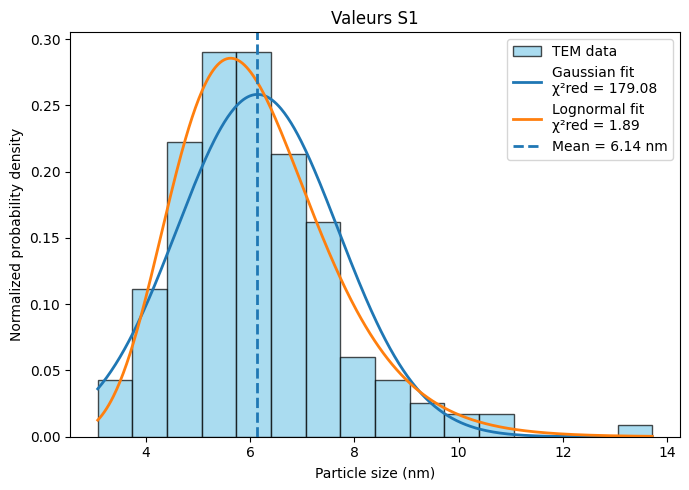


Résultats pour Valeurs S2.csv
Nombre de particules : 179
Mean                 : 7.725 nm
Standard deviation   : 1.933 nm
SEM                  : 0.144 nm
Reduced χ² (Gaussian)  : 3.423
Reduced χ² (Lognormal) : 2.337


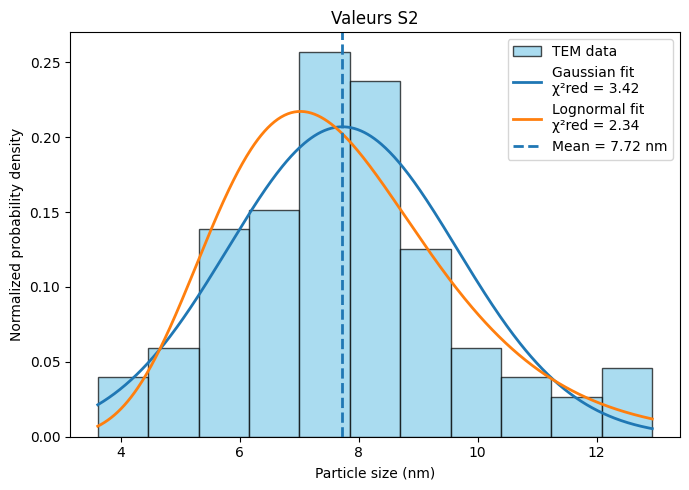


Résultats pour Valeurs S4.csv
Nombre de particules : 179
Mean                 : 8.350 nm
Standard deviation   : 1.789 nm
SEM                  : 0.134 nm
Reduced χ² (Gaussian)  : 4.507
Reduced χ² (Lognormal) : 1.272


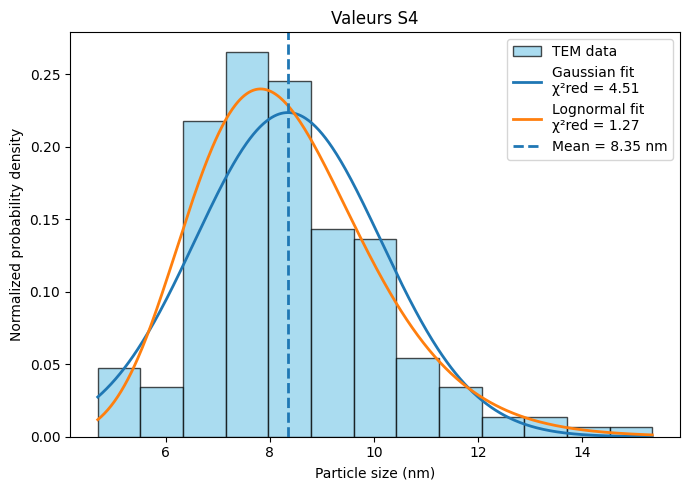

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm, lognorm


# =========================================================
# LISTE DES FICHIERS
# =========================================================

files = [
    "Valeurs S1.csv",
    "Valeurs S2.csv",
    "Valeurs S4.csv"
]


# =========================================================
# ANALYSE
# =========================================================

for file in files:

    df = pd.read_csv(file)
    df.columns = df.columns.str.strip()

    lengths = df["Length"].dropna().values
    lengths = lengths[lengths > 0]

    N = len(lengths)
    mean = np.mean(lengths)
    std = np.std(lengths, ddof=1)
    sem = std / np.sqrt(N)

    print("\n====================================")
    print(f"Résultats pour {file}")
    print("====================================")
    print(f"Nombre de particules : {N}")
    print(f"Mean                 : {mean:.3f} nm")
    print(f"Standard deviation   : {std:.3f} nm")
    print(f"SEM                  : {sem:.3f} nm")

    # -----------------------------------------------------
    # BINS
    # -----------------------------------------------------

    q75, q25 = np.percentile(lengths, [75, 25])
    iqr = q75 - q25

    bin_width = 2 * iqr / (N ** (1/3))

    if bin_width <= 0:
        bin_width = 1

    bins = int((lengths.max() - lengths.min()) / bin_width)
    bins = max(bins, 8)

    counts, edges = np.histogram(lengths, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    bin_widths = np.diff(edges)

    # -----------------------------------------------------
    # FITS SUR LES DONNÉES
    # -----------------------------------------------------

    mu_gauss, sigma_gauss = norm.fit(lengths)

    shape_logn, loc_logn, scale_logn = lognorm.fit(lengths, floc=0)

    # -----------------------------------------------------
    # CHI² SUR COUNTS
    # expected counts = PDF * N * largeur du bin
    # -----------------------------------------------------

    expected_gauss = norm.pdf(centers, mu_gauss, sigma_gauss) * N * bin_widths

    expected_logn = lognorm.pdf(
        centers,
        shape_logn,
        loc=loc_logn,
        scale=scale_logn
    ) * N * bin_widths

    mask_gauss = (counts > 0) & (expected_gauss > 0)
    mask_logn = (counts > 0) & (expected_logn > 0)

    chi2_gauss = np.sum(
        (counts[mask_gauss] - expected_gauss[mask_gauss])**2
        / expected_gauss[mask_gauss]
    )

    chi2_logn = np.sum(
        (counts[mask_logn] - expected_logn[mask_logn])**2
        / expected_logn[mask_logn]
    )

    dof_gauss = np.sum(mask_gauss) - 2
    dof_logn = np.sum(mask_logn) - 2

    reduced_chi2_gauss = chi2_gauss / dof_gauss
    reduced_chi2_logn = chi2_logn / dof_logn

    print(f"Reduced χ² (Gaussian)  : {reduced_chi2_gauss:.3f}")
    print(f"Reduced χ² (Lognormal) : {reduced_chi2_logn:.3f}")

    # -----------------------------------------------------
    # PLOT NORMALISÉ
    # -----------------------------------------------------

    x_fit = np.linspace(lengths.min(), lengths.max(), 500)

    y_gauss = norm.pdf(x_fit, mu_gauss, sigma_gauss)

    y_logn = lognorm.pdf(
        x_fit,
        shape_logn,
        loc=loc_logn,
        scale=scale_logn
    )

    plt.figure(figsize=(7, 5))

    plt.hist(
        lengths,
        bins=bins,
        density=True,
        alpha=0.7,
        color="skyblue",
        edgecolor="black",
        label="TEM data"
    )

    plt.plot(
        x_fit,
        y_gauss,
        linewidth=2,
        label=f"Gaussian fit\nχ²red = {reduced_chi2_gauss:.2f}"
    )

    plt.plot(
        x_fit,
        y_logn,
        linewidth=2,
        label=f"Lognormal fit\nχ²red = {reduced_chi2_logn:.2f}"
    )

    plt.axvline(
        mean,
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean:.2f} nm"
    )

    plt.xlabel("Particle size (nm)")
    plt.ylabel("Normalized probability density")

    plt.title(file.replace(".csv", ""))
    plt.legend()
    plt.tight_layout()

    output_name = file.replace(".csv", "_analysis_normalized.png")

    plt.savefig(output_name, dpi=300)
    plt.show()